In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
data2=pd.read_csv("../data/amazon_product_reviews.csv")
data2.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


In [56]:
data2=data2[["review_body","sentiment"]]
data2.dropna(subset=["review_body","sentiment"],inplace=True)
#data2=data2[data2["sentiment"]<3]
data2.head()

,review_body,sentiment
0,Great love it,1
1,Lots of ads<br />Slow processing speed<br />Oc...,0
2,Excellent unit. The versatility of this table...,1
3,I bought this on Amazon Prime so I ended up bu...,1
4,All Amazon products continue to meet my expect...,1


In [57]:
data2["sentiment"].value_counts()

sentiment
1    25764
0     5078
Name: count, dtype: int64

In [58]:
data1=pd.read_csv("../data/amazon_alexa.tsv",sep='\t')
data1.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [59]:
data2.rename(columns={
    "review_body": "verified_reviews",
    "sentiment": "feedback"
}, inplace=True)

data2["rating"]=5
data2["date"]="01-Jan-20"
data2["variation"]="unknown"
data2 = data2[["rating", "date", "variation", "verified_reviews", "feedback"]]
data2.head()


,rating,date,variation,verified_reviews,feedback
0,5,01-Jan-20,unknown,Great love it,1
1,5,01-Jan-20,unknown,Lots of ads<br />Slow processing speed<br />Oc...,0
2,5,01-Jan-20,unknown,Excellent unit. The versatility of this table...,1
3,5,01-Jan-20,unknown,I bought this on Amazon Prime so I ended up bu...,1
4,5,01-Jan-20,unknown,All Amazon products continue to meet my expect...,1


In [60]:
positive_samples = data2[data2["feedback"] == 1].sample(n=2500, random_state=42)
negative_samples = data2[data2["feedback"] == 0].sample(n=5000, random_state=42)
combined_new = pd.concat([positive_samples, negative_samples], ignore_index=True)

In [61]:
data = pd.concat([data1, combined_new], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print("Final data shape-",data.shape)
data.head()

Final data shape- (10650, 5)


,rating,date,variation,verified_reviews,feedback
0,5,01-Jan-20,unknown,Great we all have kindle. We love them as well...,1
1,5,01-Jan-20,unknown,"If I could give this product zero stars, I wou...",0
2,5,01-Jan-20,unknown,I really like my new Kindle the only way I cou...,1
3,5,01-Jan-20,unknown,There is no point to own a tablet without Goog...,0
4,5,01-Jan-20,unknown,"I really like it, but I can't get to Amazon to...",1


In [62]:
column_names=data.columns.values
column_names

array(['rating', 'date', 'variation', 'verified_reviews', 'feedback'],
      dtype=object)

In [63]:
data.shape


(10650, 5)

In [64]:
data["feedback"].value_counts()

feedback
1    5393
0    5257
Name: count, dtype: int64

In [65]:
data.describe()

,rating,feedback
count,10650.000000,10650.000000
mean,4.841221,0.506385
std,0.630590,0.499983
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [66]:
# checking for null values
data.isna().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [67]:
data[data["verified_reviews"].isna()==True]

,rating,date,variation,verified_reviews,feedback
2752,2,29-Jun-18,White,NaN,0


In [68]:
# removed null values
data=data.dropna()
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

In [69]:
print("The dataset shape after removing null values is",data.shape)

The dataset shape after removing null values is (10649, 5)


In [70]:
#creating a new column that contains the length of the string in the verified reviews column
data["length"]=data["verified_reviews"].apply(len)
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,01-Jan-20,unknown,Great we all have kindle. We love them as well...,1,127
1,5,01-Jan-20,unknown,"If I could give this product zero stars, I wou...",0,474
2,5,01-Jan-20,unknown,I really like my new Kindle the only way I cou...,1,129
3,5,01-Jan-20,unknown,There is no point to own a tablet without Goog...,0,294
4,5,01-Jan-20,unknown,"I really like it, but I can't get to Amazon to...",1,272


In [71]:
#checking if the values in length column is accurate
print(f"'verified_review' column value:{data.iloc[9]["verified_reviews"]}")
print(f"Length of the review:{len(data.iloc[9]["verified_reviews"])}")
print(f"'length' column value:{data.iloc[9]["length"]}")

'verified_review' column value:I love my fire stick
Length of the review:20
'length' column value:20


In [72]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

In [73]:
#analysing rating column
data["rating"].value_counts()

rating
5    9786
4     455
1     161
3     152
2      95
Name: count, dtype: int64

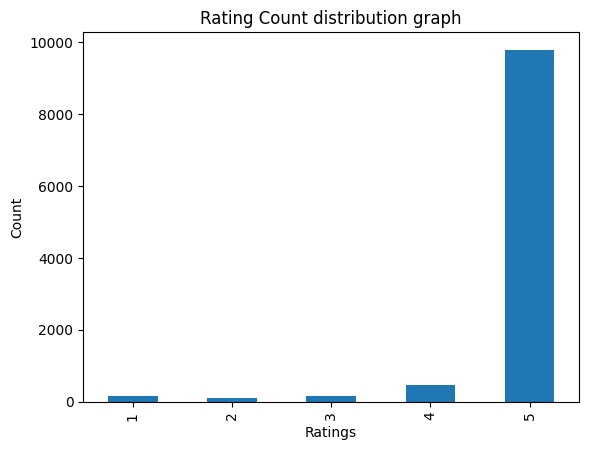

In [74]:
#rating distribution graph
rating_counts=data["rating"].value_counts().sort_index()
rating_counts
rating_counts.plot(kind="bar")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.title("Rating Count distribution graph")
plt.show()

In [75]:
#calculating the rating count distribution percentage
print(f"Rating values distribution in percentage:{round(data['rating'].value_counts()/data.shape[0]*100,2)}")

Rating values distribution in percentage:rating
5    91.90
4     4.27
1     1.51
3     1.43
2     0.89
Name: count, dtype: float64


In [76]:
rating_counts_percent=round(data['rating'].value_counts()/data.shape[0]*100,2)
df1=pd.DataFrame(rating_counts_percent)
df1.head()

,count
rating,
5,91.90
4,4.27
1,1.51
3,1.43
2,0.89


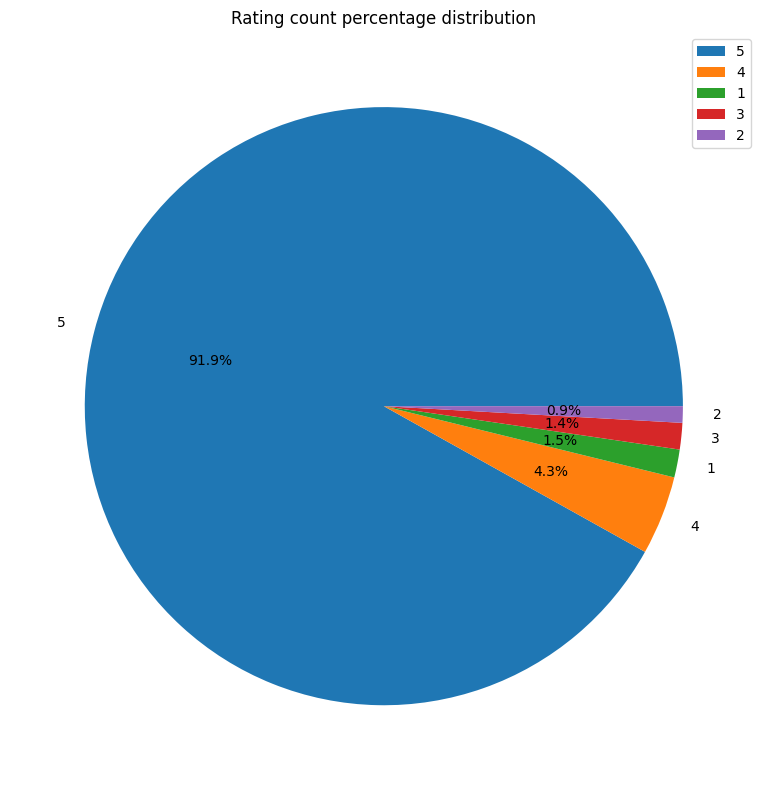

In [77]:
plt.figure(figsize=(14,8))
plt.pie(rating_counts_percent,labels=rating_counts_percent.index,autopct="%1.1f%%")
plt.title("Rating count percentage distribution")
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

In [78]:
#analysing feedback column
print(f"Feedback column value counts: \n{data['feedback'].value_counts()}")

Feedback column value counts: 
feedback
1    5393
0    5256
Name: count, dtype: int64


In [79]:
# 0 means negative feedback and 1 means positive feedback

In [80]:
feedback_counts=data["feedback"].value_counts()
df2=pd.DataFrame(feedback_counts)
df2.head()

,count
feedback,
1,5393
0,5256


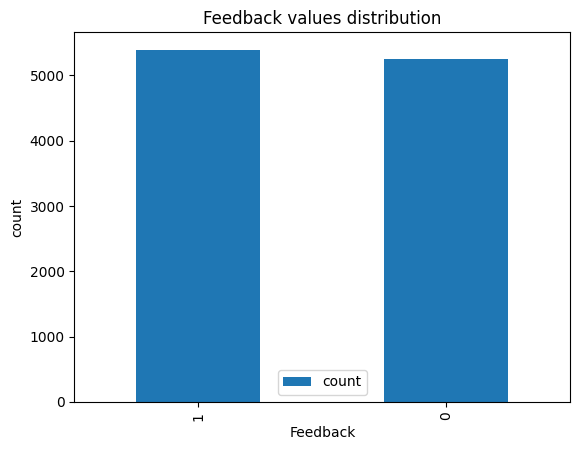

In [81]:
#feedback column values distribution
df2.plot(kind="bar")
plt.xlabel("Feedback")
plt.ylabel("count")
plt.title("Feedback values distribution")
plt.show()

In [82]:
#calculating the feedback count distribution percentage
print(f"feedback values distribution in percentage:{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

feedback values distribution in percentage:feedback
1    50.64
0    49.36
Name: count, dtype: float64


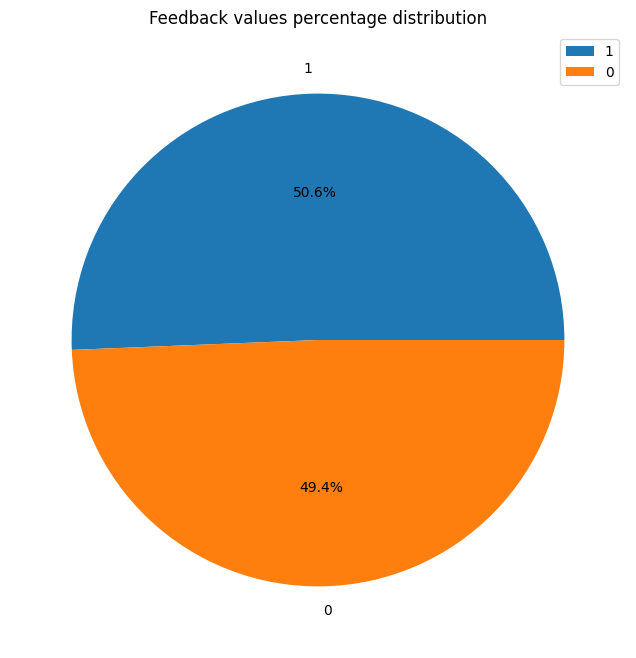

In [83]:
#feedback column values percent distribution
feedback_counts_percent=round(data['feedback'].value_counts()/data.shape[0]*100,2)
plt.figure(figsize=(15,8))
plt.pie(feedback_counts_percent.values,labels=feedback_counts_percent.index,autopct="%1.1f%%")
plt.legend()
plt.title("Feedback values percentage distribution")
plt.show()

In [84]:
#rating values for different values of feedback
data[data["feedback"]==0]["rating"].value_counts()

rating
5    5000
1     161
2      95
Name: count, dtype: int64

In [85]:
data[data["feedback"]==1]["rating"].value_counts()

rating
5    4786
4     455
3     152
Name: count, dtype: int64

In [86]:
# rating of 1 and 2 are considered negative reviews and rating of 4,5 are considered as positive reviews. 3 as neutral

In [87]:
#analysing variation column
data["variation"].value_counts()

variation
unknown                         7500
Black  Dot                       516
Charcoal Fabric                  430
Configuration: Fire TV Stick     350
Black  Plus                      270
Black  Show                      265
Black                            261
Black  Spot                      241
White  Dot                       184
Heather Gray Fabric              157
White  Spot                      109
White                             90
Sandstone Fabric                  90
White  Show                       85
White  Plus                       78
Oak Finish                        14
Walnut Finish                      9
Name: count, dtype: int64

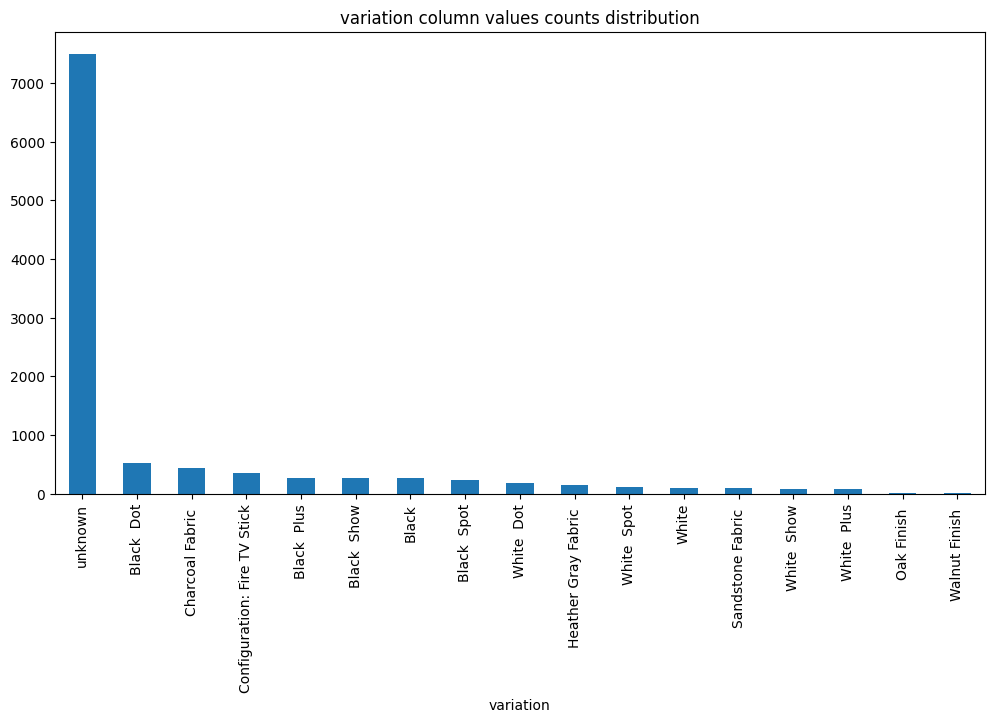

In [88]:
plt.figure(figsize=(12,6))
variation_counts=data["variation"].value_counts()
variation_counts.plot(kind="bar",x=variation_counts.index,y=variation_counts.values)
plt.title("variation column values counts distribution")
plt.show()

In [89]:
#variation vs rating
data.groupby("variation")["rating"].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.166667
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
unknown                         5.000000
Name: rating, dtype: float64

Text(0.5, 1.0, 'Distribution of length of review')

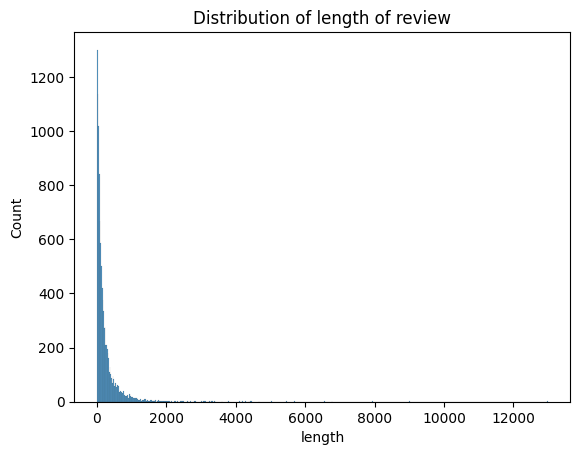

In [90]:
#analysing verified reviews column
sns.histplot(data["length"])
plt.title("Distribution of length of review")

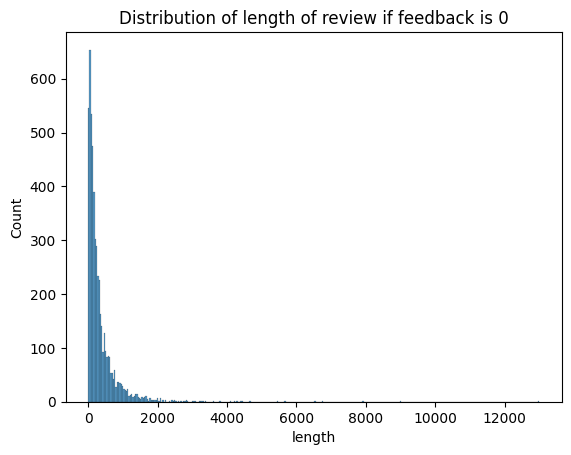

In [91]:
#distribution of length of review if feedback=0
sns.histplot(data[data["feedback"]==0]["length"])
plt.title("Distribution of length of review if feedback is 0")
plt.show()

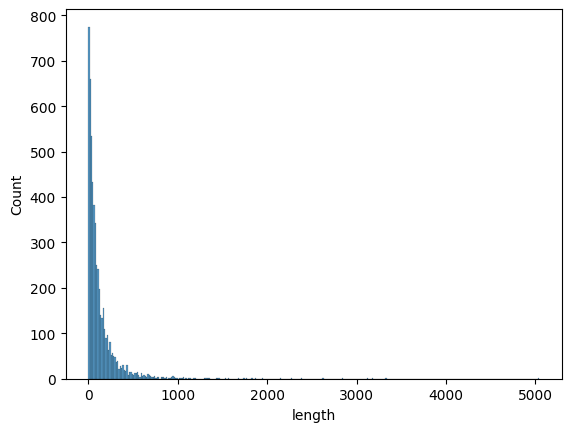

In [92]:
#distrbution of length of review if feedback is 1
sns.histplot(data[data["feedback"]==1]["length"])
plt.show("Distribution of length of reviews if feedback is 1")
plt.show()

In [93]:
#the length of the reviews are shorted when the feedback=0 comparatively.

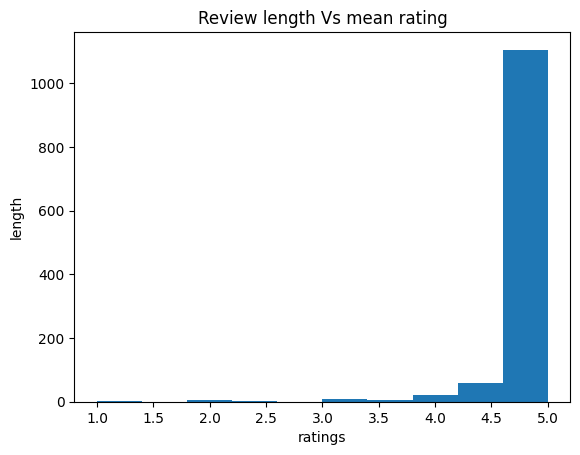

In [94]:
#length vs rating
data.groupby('length')["rating"].mean().plot.hist()
plt.title("Review length Vs mean rating")
plt.xlabel("ratings")
plt.ylabel("length")
plt.show()

In [95]:
#users writes lenghty reviews for positive and a much shorter for negative

In [96]:
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
STOPWORDS=set(stopwords.words("english"))
from wordcloud import WordCloud

In [97]:
#vectorising
cv=CountVectorizer(stop_words="english")
words=cv.fit_transform(data.verified_reviews)
words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 175936 stored elements and shape (10649, 10709)>

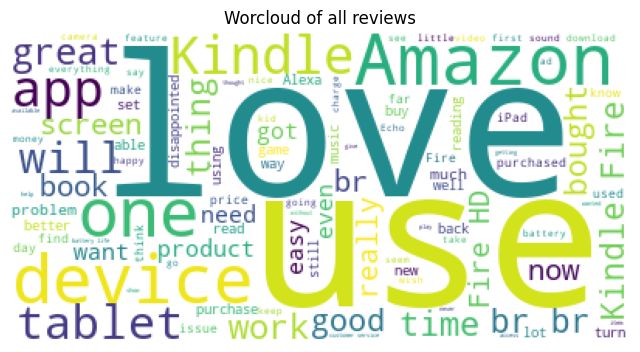

In [105]:
#combining all reviews and generating wordcloud
reviews=" ".join([review for review in data["verified_reviews"]])
wc=WordCloud(background_color="white",max_words=100)
plt.figure(figsize=(8,8))
plt.imshow(wc.generate(reviews))
plt.axis("off")
plt.title("Worcloud of all reviews")
plt.show()

In [99]:
#extarcting only the negative reviews
negative_reviews=" ".join([review for review in data[data["feedback"]==0]["verified_reviews"]])
negative_reviews=negative_reviews.lower().split()
negative_reviews[0:10]

['if',
 'i',
 'could',
 'give',
 'this',
 'product',
 'zero',
 'stars,',
 'i',
 'would.']

In [100]:
#extracting only the postive reviews
positive_reviews=" ".join([review for review in data[data["feedback"]==1]["verified_reviews"]])
positive_reviews=positive_reviews.lower().split()
positive_reviews[0:10]

['great', 'we', 'all', 'have', 'kindle.', 'we', 'love', 'them', 'as', 'well']

In [101]:
#finding unique negative and positive words

unique_pos_words=[x for x in positive_reviews if x not in negative_reviews]
unique_pos_words=" ".join(unique_pos_words)
unique_neg_words=[x for x in negative_reviews if x not in positive_reviews]
unique_neg_words=" ".join(unique_neg_words)

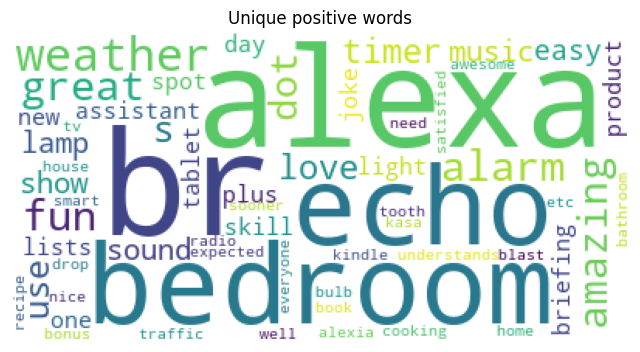

In [102]:
#wordcloud of unique negative positive words
plt.figure(figsize=(8,8))
plt.imshow(wc.generate(unique_pos_words))
plt.title("Unique positive words")
plt.axis("off")
plt.show()

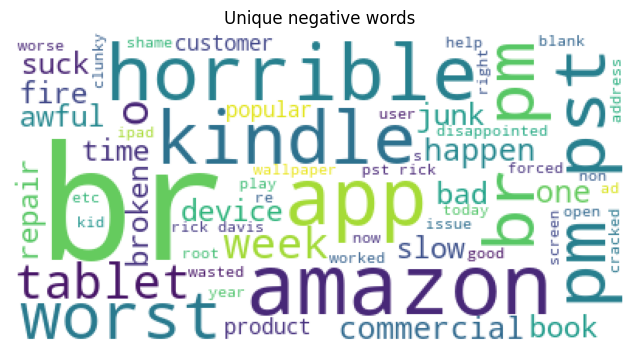

In [103]:
#wordcloud of unique negative words
plt.figure(figsize=(8,8))
plt.imshow(wc.generate(unique_neg_words))
plt.axis("off")
plt.title("Unique negative words")
plt.show()

In [106]:
#save the cleaned dataset
data.to_csv("../data/amazon_data_cleaned.csv",index=False)